# EfficientNet-B3 Training - Micro Dataset (Kaggle)

This notebook trains a 3-class EfficientNet-B3 classifier for microplastic crops:
- fiber
- film
- fragment

It is adapted for your micro scenario and Kaggle runtime:
- Auto-detect dataset in `/kaggle/input`
- Copy dataset to `/kaggle/working`
- Use split-aware loading from `annotations.json` (`train` / `val`)
- Two-stage training for high accuracy and robust generalization

## Training Strategy
1. Stage A: freeze backbone, train classifier head
2. Stage B: unfreeze full model, fine-tune with lower LR
3. Weighted sampling + class-weighted loss
4. Mixed precision, cosine schedule, early stopping

## 1. Install Dependencies

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'timm', 'scikit-learn', 'seaborn'], check=True)
print('Dependencies installed.')

Dependencies installed.


## 2. GPU Check + Reproducibility

In [2]:
import os
import random
import numpy as np
import torch
import psutil

assert torch.cuda.is_available(), 'No GPU detected. In Kaggle, set Accelerator to GPU.'

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")
print(f"RAM total: {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"Disk free: {psutil.disk_usage('/kaggle/working').free / 1e9:.1f} GB")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print(f"Seed: {SEED}")

GPU: Tesla T4
PyTorch: 2.9.0+cu126
CUDA: 12.6
RAM total: 33.7 GB
Disk free: 20.9 GB
Seed: 42


## 3. Auto-Detect Micro Dataset + Copy to /kaggle/working

In [3]:
import shutil
from pathlib import Path

INPUT_ROOT = Path('/kaggle/input')
LOCAL_DATASET = Path('/kaggle/working/micro_crops_augmented')
OUTPUT_ROOT = Path('/kaggle/working/experiments/efficientnet/micro_effnet_b3_cls3')
BACKUP_ROOT = Path('/kaggle/working/backups/efficientnet_micro')

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

print('Top-level /kaggle/input entries:')
print(sorted([p.name for p in INPUT_ROOT.iterdir()]))

candidates = []
for p in INPUT_ROOT.rglob('*'):
    if not p.is_dir():
        continue

    has_class_dirs = all((p / c).is_dir() for c in ['fiber', 'film', 'fragment'])
    has_annotations = (p / 'annotations.json').exists()
    has_images = (p / 'images').is_dir()

    if has_class_dirs and (has_annotations or has_images):
        score = 0
        s = str(p).lower()
        if 'micro' in s:
            score += 5
        if 'crops_augmented' in s:
            score += 4
        if 'crops' in s:
            score += 2
        candidates.append((score, p))

assert candidates, 'No valid crop dataset found in /kaggle/input.'
candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
SRC_DATASET = candidates[0][1]
print(f'Using dataset source: {SRC_DATASET}')

if LOCAL_DATASET.exists():
    print(f'Dataset already copied: {LOCAL_DATASET}')
else:
    print(f'Copying dataset to {LOCAL_DATASET} ...')
    shutil.copytree(str(SRC_DATASET), str(LOCAL_DATASET))
    print('Copy complete.')

print('Dataset ready.')

Top-level /kaggle/input entries:
['datasets']
Using dataset source: /kaggle/input/datasets/mpdetect/crops-augmented-micro
Copying dataset to /kaggle/working/micro_crops_augmented ...
Copy complete.
Dataset ready.


## 4. Dataset Class + Transforms

In [4]:
import json
from PIL import Image
from collections import Counter

from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms

NUM_CLASSES = 3
CLASS_NAMES = ['fiber', 'film', 'fragment']
CLASS_NAME_TO_ID = {'fiber': 0, 'film': 1, 'fragment': 2}
IMG_SIZE = 300

class CropClassificationDataset(Dataset):
    """Supports:
      1) annotations.json + split field + images/
      2) root/{train,val}/{fiber,film,fragment}/*
      3) root/{fiber,film,fragment}/*
    """
    def __init__(self, crops_dir, transform=None, split=None):
        self.crops_dir = Path(crops_dir)
        self.transform = transform
        self.samples = []

        ann_file = self.crops_dir / 'annotations.json'
        split_dir = self.crops_dir / split if split else None
        has_split_dirs = split_dir is not None and split_dir.is_dir() and any((split_dir / cn).is_dir() for cn in CLASS_NAMES)

        if has_split_dirs:
            for cls_name, cls_id in CLASS_NAME_TO_ID.items():
                cls_dir = split_dir / cls_name
                if not cls_dir.is_dir():
                    continue
                for f in sorted(cls_dir.glob('*')):
                    if f.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'):
                        self.samples.append((str(f), cls_id))

        elif ann_file.exists():
            with open(ann_file) as f:
                annotations = json.load(f)

            for filename, ann in annotations.items():
                if split and ann.get('split', '') != split:
                    continue

                cls_id = ann.get('class_id', CLASS_NAME_TO_ID.get(ann.get('class_name', ''), None))
                if cls_id is None:
                    continue

                img_path = self.crops_dir / 'images' / filename
                if not img_path.exists():
                    cls_name = ann.get('class_name', CLASS_NAMES[cls_id])
                    img_path = self.crops_dir / cls_name / filename

                if img_path.exists():
                    self.samples.append((str(img_path), int(cls_id)))

        else:
            for cls_name, cls_id in CLASS_NAME_TO_ID.items():
                cls_dir = self.crops_dir / cls_name
                if not cls_dir.is_dir():
                    continue
                for f in sorted(cls_dir.glob('*')):
                    if f.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'):
                        self.samples.append((str(f), cls_id))

        counts = [0, 0, 0]
        for _, cls_id in self.samples:
            counts[int(cls_id)] += 1

        split_text = f' ({split})' if split else ''
        print(f'Loaded {len(self.samples)} samples{split_text} from {crops_dir}')
        for i, n in enumerate(CLASS_NAMES):
            print(f'  {n}: {counts[i]}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(25),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.12)),
            transforms.ColorJitter(brightness=0.22, contrast=0.22, saturation=0.18, hue=0.03),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

print('Dataset and transforms ready.')

Dataset and transforms ready.


## 5. Build Loaders + Balance Handling

In [5]:
EPOCHS_HEAD = 12
EPOCHS_FINE = 68
BATCH_SIZE = 16
LR_HEAD = 3e-4
LR_FINE = 7e-5
WEIGHT_DECAY = 1e-2
VAL_SPLIT = 0.2
EARLY_STOP_PATIENCE = 14
LABEL_SMOOTHING = 0.05
BACKUP_EVERY = 5

crops_path = LOCAL_DATASET
ann_file = crops_path / 'annotations.json'
has_split_dirs = (crops_path / 'train').is_dir() and all((crops_path / 'train' / c).is_dir() for c in CLASS_NAMES)

has_ann_splits = False
if ann_file.exists():
    with open(ann_file) as f:
        anns = json.load(f)
    has_ann_splits = any('split' in v for v in anns.values())

if has_split_dirs or has_ann_splits:
    train_dataset = CropClassificationDataset(str(crops_path), transform=get_transforms(train=True), split='train')
    val_dataset = CropClassificationDataset(str(crops_path), transform=get_transforms(train=False), split='val')
else:
    full_dataset = CropClassificationDataset(str(crops_path), transform=get_transforms(train=True))
    val_size = int(len(full_dataset) * VAL_SPLIT)
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
    print(f'Random split -> train: {train_size}, val: {val_size}')

if isinstance(train_dataset, torch.utils.data.Subset):
    base = train_dataset.dataset
    idxs = train_dataset.indices
    labels = [base.samples[i][1] for i in idxs]
else:
    labels = [x[1] for x in train_dataset.samples]

label_counts = Counter(labels)
sample_weights = [1.0 / label_counts[l] for l in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

counts = np.array([label_counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights = 1.0 / np.maximum(counts, 1)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print('Class weights:', class_weights.numpy())

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=use_cuda, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=use_cuda, persistent_workers=True)

print('Dataloaders ready.')

Loaded 2400 samples (train) from /kaggle/working/micro_crops_augmented
  fiber: 800
  film: 800
  fragment: 800
Loaded 600 samples (val) from /kaggle/working/micro_crops_augmented
  fiber: 200
  film: 200
  fragment: 200
Class weights: [1. 1. 1.]
Dataloaders ready.


## 6. Model + Training Utilities

In [6]:
import timm
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_model(freeze_backbone=False):
    model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=NUM_CLASSES)
    if freeze_backbone:
        for name, p in model.named_parameters():
            if 'classifier' not in name:
                p.requires_grad = False
    return model

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    all_true, all_pred = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)

            if train_mode:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        preds = logits.argmax(1)
        total_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(len(loader), 1)
    acc = correct / max(total, 1)
    return avg_loss, acc, all_true, all_pred

def train_stage(model, train_loader, val_loader, epochs, lr, stage_name, start_epoch=0, best_acc=0.0):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.05)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTHING)
    scaler = torch.amp.GradScaler(device=device.type, enabled=(device.type == 'cuda'))

    history = []
    no_improve = 0

    print('')
    print('=' * 90)
    print(f'STAGE: {stage_name}')
    print(f'Epochs: {epochs} | LR: {lr} | Trainable params: {sum(p.numel() for p in params):,}')
    print('=' * 90)

    for e in range(epochs):
        epoch_num = start_epoch + e + 1

        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
        va_loss, va_acc, y_true, y_pred = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)
        scheduler.step()

        history.append({
            'epoch': epoch_num,
            'train_loss': tr_loss,
            'train_acc': tr_acc,
            'val_loss': va_loss,
            'val_acc': va_acc,
        })

        print(f'Epoch {epoch_num:03d} | train_loss={tr_loss:.4f} train_acc={tr_acc:.2%} | val_loss={va_loss:.4f} val_acc={va_acc:.2%}')

        ckpt = {
            'epoch': epoch_num,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': va_acc,
            'history': history,
            'stage': stage_name,
        }
        torch.save(ckpt, OUTPUT_ROOT / 'efficientnet_latest.pth')

        if va_acc > best_acc:
            best_acc = va_acc
            no_improve = 0
            torch.save(ckpt, OUTPUT_ROOT / 'efficientnet_best.pth')
            print(f'  -> new best: {best_acc:.2%}')
        else:
            no_improve += 1

        if epoch_num % BACKUP_EVERY == 0:
            bdir = BACKUP_ROOT / f'epoch_{epoch_num:04d}'
            bdir.mkdir(parents=True, exist_ok=True)
            for fn in ['efficientnet_latest.pth', 'efficientnet_best.pth']:
                src = OUTPUT_ROOT / fn
                if src.exists():
                    shutil.copy2(str(src), str(bdir / fn))
            print(f'  [AUTO-BACKUP] {bdir}')

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'  [EARLY STOP] no improvement for {EARLY_STOP_PATIENCE} epochs')
            break

    return best_acc, history

print('Training utilities ready.')

Training utilities ready.


## 7. Train (Head Warmup + Full Fine-Tuning)

In [7]:
model = get_model(freeze_backbone=True).to(device)
best_acc = 0.0
all_history = []

best_acc, h1 = train_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_HEAD,
    lr=LR_HEAD,
    stage_name='head_warmup',
    start_epoch=0,
    best_acc=best_acc
)
all_history.extend(h1)

for p in model.parameters():
    p.requires_grad = True

best_acc, h2 = train_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_FINE,
    lr=LR_FINE,
    stage_name='full_finetune',
    start_epoch=len(all_history),
    best_acc=best_acc
)
all_history.extend(h2)

print('')
print('=' * 90)
print('TRAINING COMPLETE')
print(f'Best val acc: {best_acc:.2%}')
print(f'Best checkpoint: {OUTPUT_ROOT / "efficientnet_best.pth"}')
print('=' * 90)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


STAGE: head_warmup
Epochs: 12 | LR: 0.0003 | Trainable params: 4,611
Epoch 001 | train_loss=2.7844 train_acc=29.79% | val_loss=3.3814 val_acc=26.33%
  -> new best: 26.33%
Epoch 002 | train_loss=2.0436 train_acc=41.67% | val_loss=2.6496 val_acc=38.00%
  -> new best: 38.00%
Epoch 003 | train_loss=1.5522 train_acc=52.00% | val_loss=2.1791 val_acc=43.83%
  -> new best: 43.83%
Epoch 004 | train_loss=1.3129 train_acc=59.54% | val_loss=1.9464 val_acc=49.00%
  -> new best: 49.00%
Epoch 005 | train_loss=1.1393 train_acc=64.92% | val_loss=1.6293 val_acc=56.00%
  -> new best: 56.00%
  [AUTO-BACKUP] /kaggle/working/backups/efficientnet_micro/epoch_0005
Epoch 006 | train_loss=1.0896 train_acc=67.79% | val_loss=1.6174 val_acc=58.17%
  -> new best: 58.17%
Epoch 007 | train_loss=1.0269 train_acc=68.75% | val_loss=1.4864 val_acc=59.50%
  -> new best: 59.50%
Epoch 008 | train_loss=0.9393 train_acc=71.46% | val_loss=1.4381 val_acc=60.83%
  -> new best: 60.83%
Epoch 009 | train_loss=0.8875 train_acc=73.7

## 8. Curves + Validation Metrics

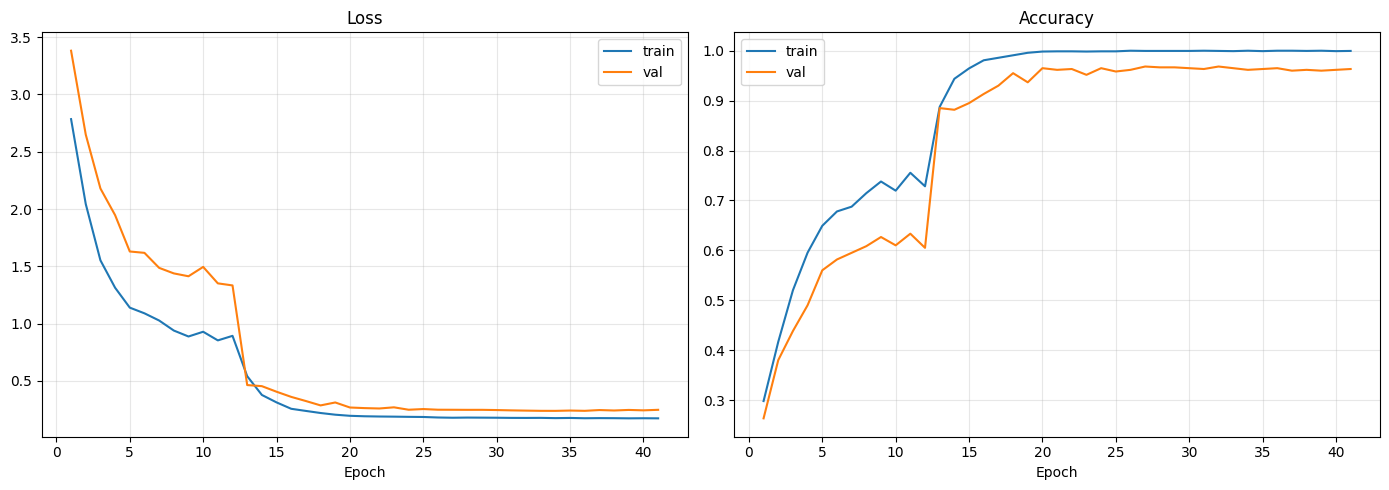

Best model val_acc: 96.83%


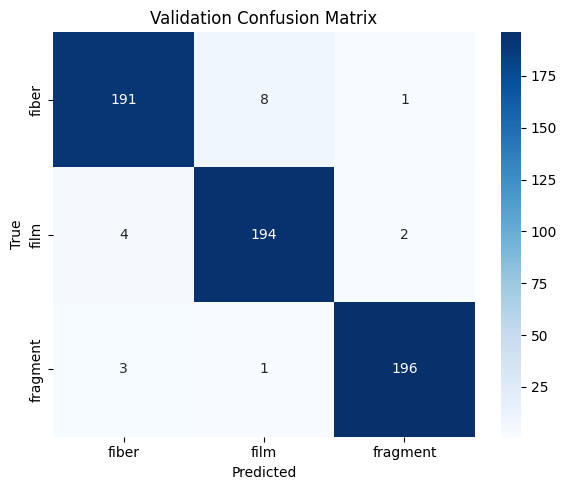

Classification report:
              precision    recall  f1-score   support

       fiber     0.9646    0.9550    0.9598       200
        film     0.9557    0.9700    0.9628       200
    fragment     0.9849    0.9800    0.9825       200

    accuracy                         0.9683       600
   macro avg     0.9684    0.9683    0.9683       600
weighted avg     0.9684    0.9683    0.9683       600



In [8]:
epochs = [x['epoch'] for x in all_history]
tr_loss = [x['train_loss'] for x in all_history]
va_loss = [x['val_loss'] for x in all_history]
tr_acc = [x['train_acc'] for x in all_history]
va_acc = [x['val_acc'] for x in all_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, tr_loss, label='train')
axes[0].plot(epochs, va_loss, label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, tr_acc, label='train')
axes[1].plot(epochs, va_acc, label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_micro_training_curves.png', dpi=150)
plt.show()

best_ckpt = torch.load(OUTPUT_ROOT / 'efficientnet_best.pth', map_location=device, weights_only=False)
model = get_model(freeze_backbone=False).to(device)
model.load_state_dict(best_ckpt['model_state_dict'])

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTHING)
va_loss, va_acc, y_true, y_pred = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)
print(f'Best model val_acc: {va_acc:.2%}')

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_micro_confusion_matrix.png', dpi=150)
plt.show()

print('Classification report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

## 9. Saved Artifacts

In [9]:
print('Saved checkpoints:')
for p in sorted(OUTPUT_ROOT.glob('*.pth')):
    print(f'- {p} ({p.stat().st_size / 1e6:.1f} MB)')

print('')
print('Additional outputs:')
for p in [
    Path('/kaggle/working/efficientnet_micro_training_curves.png'),
    Path('/kaggle/working/efficientnet_micro_confusion_matrix.png'),
]:
    if p.exists():
        print(f'- {p}')

print('')
print('Download in Kaggle Output tab:')
print('- /kaggle/working/experiments/efficientnet/micro_effnet_b3_cls3/efficientnet_best.pth')

Saved checkpoints:
- /kaggle/working/experiments/efficientnet/micro_effnet_b3_cls3/efficientnet_best.pth (129.3 MB)
- /kaggle/working/experiments/efficientnet/micro_effnet_b3_cls3/efficientnet_latest.pth (129.3 MB)

Additional outputs:
- /kaggle/working/efficientnet_micro_training_curves.png
- /kaggle/working/efficientnet_micro_confusion_matrix.png

Download in Kaggle Output tab:
- /kaggle/working/experiments/efficientnet/micro_effnet_b3_cls3/efficientnet_best.pth
